In [7]:
# CELL 1 — Install
!pip install -q unsloth
!pip install -q "trl>=0.15.0" "datasets" "openai" "httpx" "matplotlib" "peft" "accelerate"
!pip install -q mergekit
import torch, transformers, trl, unsloth, peft
print(f"torch: {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"trl: {trl.__version__}")
print(f"unsloth: {unsloth.__version__}")
print(f"peft: {peft.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — change runtime to T4'}")
print("Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.7/431.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 45.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires click!=8.2.*,>=4.0, but you have click 8.2.1 which is incompatible.
mcp 1.27.0 r

In [2]:
# CELL 2 — Clone repo and setup
import os, sys

!git clone https://github.com/RAK2315/ml-debug-env.git
os.chdir('/content/ml-debug-env')
sys.path.insert(0, 'server')
sys.path.insert(0, '.')

os.environ['GROQ_API_KEY'] = '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'
os.environ['PYTHON_EXEC'] = '/usr/bin/python3'

print('Working dir:', os.getcwd())
print('Done')

Cloning into 'ml-debug-env'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 141 (delta 70), reused 106 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 316.00 KiB | 1.75 MiB/s, done.
Resolving deltas: 100% (70/70), done.
Working dir: /content/ml-debug-env
Done


In [3]:
# CELL 3 — Test environment imports
from bug_generator import get_scenario, execute_tool, ALL_TASKS, AVAILABLE_TOOLS
from grader import grade

s = get_scenario('shape_mismatch', seed=42)
print('Alert:', s.alert)
print('Tasks:', ALL_TASKS)
print('Tools:', AVAILABLE_TOOLS)
print('Done')

Alert: Training job crashed immediately. No epochs completed. Exit code 1.
Tasks: ['shape_mismatch', 'training_collapse', 'data_leakage', 'wrong_device', 'gradient_not_zeroed', 'missing_eval_mode', 'compound_shape_device', 'compound_leakage_eval']
Tools: ['run_code', 'get_traceback', 'inspect_gradients', 'print_shapes', 'view_source']
Done


In [4]:
# CELL 4 — Load model with Unsloth
import unsloth
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name='Qwen/Qwen2.5-1.5B-Instruct',
    max_seq_length=1024,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)

model.print_trainable_parameters()
print('Model loaded OK')

==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.6 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815
Model loaded OK


In [18]:
# CELL 5 — System prompt, reward function, parse_action
import json

TRAIN_SYSTEM = """You are an expert ML engineer. Debug the broken PyTorch script.
Respond with JSON only:
{"bug_type": "<shape_mismatch|training_collapse|data_leakage|wrong_device|gradient_not_zeroed|missing_eval_mode|other>", "diagnosis": "<explanation>", "fixed_code": "<complete fixed script>"}
No markdown. No text outside JSON."""

def make_train_prompt(task_id, seed=42):
    scenario = get_scenario(task_id, seed=seed)
    return [
        {"role": "system", "content": TRAIN_SYSTEM},
        {"role": "user", "content": (
            f"Broken script:\n```python\n{scenario.buggy_code}\n```\n\n"
            f"Error/failure:\n{scenario.error_output}\n\n"
            f"Return JSON fix only."
        )}
    ], scenario

def parse_action(text):
    text = text.strip()
    # try direct parse first
    try:
        return json.loads(text)
    except:
        pass
    # strip markdown fences
    if '```' in text:
        parts = text.split('```')
        for part in parts:
            part = part.strip()
            if part.startswith('json'):
                part = part[4:].strip()
            if part.startswith('{'):
                try:
                    return json.loads(part)
                except:
                    continue
    # find first { ... } block
    try:
        start = text.index('{')
        end = text.rindex('}') + 1
        return json.loads(text[start:end])
    except:
        pass
    return {}

def compute_reward(completion, task_id, seed=42):
    try:
        parsed = parse_action(completion)
        action_type = parsed.get('action_type', 'fix')
        if action_type == 'inspect':
            return 0.0
        bug_type = parsed.get('bug_type', 'other')
        diagnosis = parsed.get('diagnosis', '')
        fixed_code = parsed.get('fixed_code', '')
        if not fixed_code or len(fixed_code) < 50:
            return 0.0
        scenario = get_scenario(task_id, seed=seed)
        result = grade(
            action_bug_type=bug_type,
            action_diagnosis=diagnosis,
            fixed_code=fixed_code,
            scenario=scenario,
        )
        return float(result.score)
    except Exception as e:
        print(f"  [reward error] {e}")
        return 0.0

# Quick test
messages, scenario = make_train_prompt('shape_mismatch', seed=42)
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print('Prompt length:', len(prompt))
print('Done')

Prompt length: 1598
Done


In [20]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
# CELL 6 — GRPO training loop (fixed sequence length)
import warnings
warnings.filterwarnings('ignore')
import torch
from torch.optim import AdamW
import random

optimizer = AdamW(model.parameters(), lr=5e-6)
reward_log = []
MAX_STEPS = 200
NUM_GENERATIONS = 4

TRAIN_TASKS = ['shape_mismatch', 'training_collapse', 'wrong_device', 'gradient_not_zeroed']

def generate_completion(messages):
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to('cuda')
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=500,
            do_sample=True,
            temperature=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

dataset = []
for i in range(50):
    for task_id in TRAIN_TASKS:
        dataset.append({'task_id': task_id, 'seed': i})
random.shuffle(dataset)

step = 0
for episode in dataset:
    if step >= MAX_STEPS:
        break

    task_id = episode['task_id']
    seed = episode['seed']
    messages, scenario = make_train_prompt(task_id, seed=seed)

    completions, rewards = [], []
    for _ in range(NUM_GENERATIONS):
        completion = generate_completion(messages)
        r = compute_reward(completion, task_id, seed=seed)
        completions.append(completion)
        rewards.append(r)

    rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
    avg_reward = float(rewards_tensor.mean())
    reward_log.append({'step': step, 'reward': avg_reward})

    if rewards_tensor.std() < 1e-6:
        print(f'Step {step:3d} | {task_id:25s} | {[f"{r:.2f}" for r in rewards]} | avg={avg_reward:.3f} [no variance]')
        step += 1
        continue

    mean_r = rewards_tensor.mean()
    std_r = rewards_tensor.std() + 1e-8
    advantages = (rewards_tensor - mean_r) / std_r

    best_idx = rewards.index(max(rewards))
    advantage = advantages[best_idx].item()

    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    full_text = prompt_text + completions[best_idx]
    inputs = tokenizer(
        full_text, return_tensors='pt', truncation=True, max_length=1024
    ).to('cuda')

    model.train()
    outputs = model(**inputs, labels=inputs['input_ids'])
    loss = -advantage * outputs.loss
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    print(f'Step {step:3d} | {task_id:25s} | {[f"{r:.2f}" for r in rewards]} | avg={avg_reward:.3f}')
    step += 1

print(f'\nDone. Steps: {step}')

Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Step   0 | shape_mismatch            | ['0.00', '0.01', '0.01', '0.01'] | avg=0.007


Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Step   1 | training_collapse         | ['0.01', '0.00', '0.01', '0.00'] | avg=0.005


Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

Step 197 | training_collapse         | ['0.20', '0.00', '0.20', '0.00'] | avg=0.100


Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Step 198 | shape_mismatch            | ['0.40', '0.40', '0.40', '0.40'] | avg=0.400 [no variance]


Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Step 199 | training_collapse         | ['0.99', '0.00', '0.99', '0.20'] | avg=0.545

Done. Steps: 200


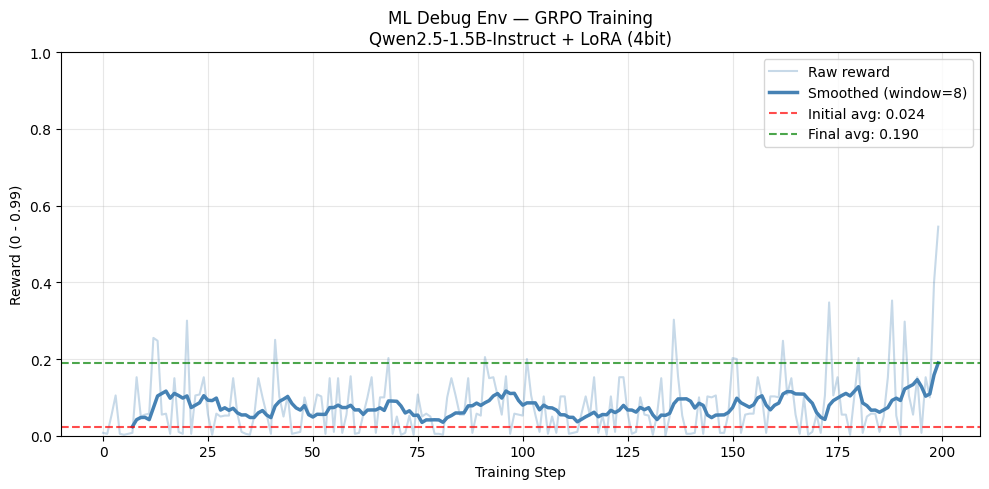

Initial reward (first 8 steps): 0.024
Final reward (last 8 steps):    0.190
Improvement: +0.166


In [22]:
# CELL 7 — Plot reward curve
import matplotlib.pyplot as plt
import numpy as np

steps = [r['step'] for r in reward_log]
rewards = [r['reward'] for r in reward_log]

window = 8
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, rewards, alpha=0.3, color='steelblue', label='Raw reward')
ax.plot(steps[window-1:], smoothed, color='steelblue', linewidth=2.5, label=f'Smoothed (window={window})')
ax.axhline(y=np.mean(rewards[:8]), color='red', linestyle='--', alpha=0.7, label=f'Initial avg: {np.mean(rewards[:8]):.3f}')
ax.axhline(y=np.mean(rewards[-8:]), color='green', linestyle='--', alpha=0.7, label=f'Final avg: {np.mean(rewards[-8:]):.3f}')
ax.set_xlabel('Training Step')
ax.set_ylabel('Reward (0 - 0.99)')
ax.set_title('ML Debug Env — GRPO Training\nQwen2.5-1.5B-Instruct + LoRA (4bit)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Initial reward (first 8 steps): {np.mean(rewards[:8]):.3f}')
print(f'Final reward (last 8 steps):    {np.mean(rewards[-8:]):.3f}')
print(f'Improvement: {np.mean(rewards[-8:]) - np.mean(rewards[:8]):+.3f}')

In [12]:
# CELL 8 — Show baseline model behavior on compound task
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

TEST_TASK = 'compound_leakage_eval'
messages = make_prompt(TEST_TASK, seed=99)
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors='pt').to('cuda')

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=600,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

response = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
reward = compute_reward(response, TEST_TASK, seed=99)
print(f'Task: {TEST_TASK}')
print(f'Score: {reward:.3f}')
print(f'Response preview: {response[:300]}')

Both `max_new_tokens` (=600) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Task: compound_leakage_eval
Score: 0.000
Response preview: ```json
{
  "action_type": "inspect",
  "tool_name": "print_shapes"
}
```


In [23]:
# CELL 9 — Save everything
import json

# Save reward log
with open('reward_log.json', 'w') as f:
    json.dump(reward_log, f)

# Save baseline score
baseline = {'task': 'compound_leakage_eval', 'seed': 99, 'score': 0.0, 'response': 'inspect:print_shapes'}
with open('baseline_result.json', 'w') as f:
    json.dump(baseline, f)

# Download reward curve
from google.colab import files
files.download('reward_curve.png')

print('Saved. Download reward_curve.png from the files panel.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved. Download reward_curve.png from the files panel.


In [17]:
# DEBUG CELL — see what model actually outputs
messages, scenario = make_train_prompt('shape_mismatch', seed=42)
completion = generate_completion(messages)
print("=== RAW OUTPUT ===")
print(completion[:1000])
print("=== REWARD ===")
print(compute_reward(completion, 'shape_mismatch', seed=42))

Both `max_new_tokens` (=1200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== RAW OUTPUT ===
```json
{
  "bug_type": "matmul_dimensions",
  "diagnosis": "The error is due to attempting a matrix multiplication between two tensors of incompatible shapes. The encoder's output shape does not match the expected input shape of the decoder.",
  "fixed_code": "def forward(self, x):\n    z = self.encoder(x)\n    return self.decoder(z)"
}
```
=== REWARD ===
0.4
